<a href="https://colab.research.google.com/github/Reemaafrin12/AirAware/blob/main/FL_BMS_IDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os, shutil
os.makedirs('data/clients', exist_ok=True)
for f in ['client_1.csv', 'client_2.csv', 'client_3.csv']:
    shutil.move(f, f'data/clients/{f}')
print(os.listdir('data/clients'))

['client_2.csv', 'client_3.csv', 'client_1.csv']


In [6]:
import os
print("power_consumption_EVSE-B-PowerCombined.csv" in os.listdir('.'))

False


In [7]:
import os
print(os.listdir('.'))

['.config', 'data', 'sample_data']


In [5]:
import os
for root, dirs, files in os.walk('/content'):
    for f in files:
        if 'power_consumption' in f.lower():
            print(os.path.join(root, f))

In [8]:
from google.colab import files
uploaded = files.upload()

Saving power_consumption_EVSE-B-PowerCombined.csv to power_consumption_EVSE-B-PowerCombined.csv


In [9]:
import os
print(os.listdir('.'))

['.config', 'data', 'power_consumption_EVSE-B-PowerCombined.csv', 'sample_data']


In [10]:
import argparse
from pathlib import Path
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score

FEATURE_COLUMNS = ["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW", "State"]
TARGET_COLUMN = "Label"
WEIGHT_COLUMN = "class_weight"
TIME_COLUMN = "time"
GROUP_COLUMN = "Attack-Group"

def chronological_group_split(data, test_size):
    train_indices, test_indices = [], []
    for group_name, group in data.groupby(GROUP_COLUMN, sort=True, dropna=False):
        ordered_group = group.sort_values(TIME_COLUMN, kind="mergesort")
        split_at = int(len(ordered_group) * (1 - test_size))
        train_indices.extend(ordered_group.index[:split_at])
        test_indices.extend(ordered_group.index[split_at:])
    return pd.Index(train_indices), pd.Index(test_indices)

client_dir = Path("data/clients")
test_size = 0.20
n_estimators = 200
random_state = 42

data = pd.concat((pd.read_csv(client_dir / f"client_{n}.csv") for n in [1, 2, 3]), ignore_index=True)
data[TIME_COLUMN] = pd.to_datetime(data[TIME_COLUMN])
train_idx, test_idx = chronological_group_split(data, test_size)

features = pd.get_dummies(data[FEATURE_COLUMNS], columns=["State"], dtype=int)
target = data[TARGET_COLUMN].astype(str)
sample_weights = pd.to_numeric(data[WEIGHT_COLUMN])

X_train, X_test = features.loc[train_idx], features.loc[test_idx]
y_train, y_test = target.loc[train_idx], target.loc[test_idx]
weights_train = sample_weights.loc[train_idx]

model = RandomForestClassifier(n_estimators=n_estimators, random_state=random_state, n_jobs=-1)
model.fit(X_train, y_train, sample_weight=weights_train)
predictions = model.predict(X_test)

print(f"Train rows: {len(X_train)} | Test rows: {len(X_test)}")
print(f"Accuracy:  {accuracy_score(y_test, predictions):.4f}")
print(f"Precision: {precision_score(y_test, predictions, pos_label='attack'):.4f}")
print(f"Recall:    {recall_score(y_test, predictions, pos_label='attack'):.4f}")
print(f"F1:        {f1_score(y_test, predictions, pos_label='attack'):.4f}")
print("Confusion matrix (attack, benign):")
print(confusion_matrix(y_test, predictions, labels=['attack', 'benign']))

Train rows: 92237 | Test rows: 23061
Accuracy:  0.9249
Precision: 0.9462
Recall:    0.9693
F1:        0.9576
Confusion matrix (attack, benign):
[[19569   619]
 [ 1112  1761]]


In [11]:
client_results = {}

for client_num in [1, 2, 3]:
    data = pd.read_csv(client_dir / f"client_{client_num}.csv")
    data[TIME_COLUMN] = pd.to_datetime(data[TIME_COLUMN])
    train_idx, test_idx = chronological_group_split(data, test_size)

    features = pd.get_dummies(data[FEATURE_COLUMNS], columns=["State"], dtype=int)
    target = data[TARGET_COLUMN].astype(str)
    sample_weights = pd.to_numeric(data[WEIGHT_COLUMN])

    X_train, X_test = features.loc[train_idx], features.loc[test_idx]
    y_train, y_test = target.loc[train_idx], target.loc[test_idx]
    weights_train = sample_weights.loc[train_idx]

    model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train, sample_weight=weights_train)
    predictions = model.predict(X_test)

    acc = accuracy_score(y_test, predictions)
    f1 = f1_score(y_test, predictions, pos_label='attack')
    client_results[f"client_{client_num}"] = (acc, f1)

    print(f"\n=== Client {client_num} ===")
    print(f"Attack groups: {sorted(data['Attack-Group'].unique())}")
    print(f"Accuracy: {acc:.4f} | F1: {f1:.4f}")
    print(confusion_matrix(y_test, predictions, labels=['attack', 'benign']))

print("\n=== Summary ===")
for name, (acc, f1) in client_results.items():
    print(f"{name}: Accuracy={acc:.4f} F1={f1:.4f}")


=== Client 1 ===
Attack groups: ['none', 'recon']
Accuracy: 0.9928 | F1: 0.9959
[[6609   55]
 [   0  958]]

=== Client 2 ===
Attack groups: ['host-attack', 'none']
Accuracy: 0.8995 | F1: 0.9444
[[6400  147]
 [ 607  351]]

=== Client 3 ===
Attack groups: ['DoS', 'none']
Accuracy: 0.9985 | F1: 0.9991
[[6965   12]
 [   0  958]]

=== Summary ===
client_1: Accuracy=0.9928 F1=0.9959
client_2: Accuracy=0.8995 F1=0.9444
client_3: Accuracy=0.9985 F1=0.9991


In [12]:
import copy
import numpy as np
from sklearn.neural_network import MLPClassifier

NUMERIC_COLUMNS = ["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW"]
LABELS = np.array(["attack", "benign"])

def make_features(data, state_categories):
    numeric = data[NUMERIC_COLUMNS].apply(pd.to_numeric, errors="raise")
    states = pd.get_dummies(data["State"].astype(str), prefix="State", dtype=float)
    state_columns = [f"State_{s}" for s in state_categories]
    states = states.reindex(columns=state_columns, fill_value=0.0)
    return np.hstack((numeric.to_numpy(dtype=float), states.to_numpy(dtype=float)))

def federated_standardization(training_features):
    total_rows = sum(len(f) for f in training_features)
    feature_sum = sum((f.sum(axis=0) for f in training_features), np.zeros(training_features[0].shape[1]))
    squared_sum = sum((np.square(f).sum(axis=0) for f in training_features), np.zeros(training_features[0].shape[1]))
    mean = feature_sum / total_rows
    variance = np.maximum(squared_sum / total_rows - np.square(mean), 0.0)
    scale = np.sqrt(variance)
    scale[scale == 0] = 1.0
    return mean, scale

def standardize(features, mean, scale):
    return (features - mean) / scale

def make_model(input_dim, hidden_units=32, lr=0.01, random_state=42):
    model = MLPClassifier(hidden_layer_sizes=(hidden_units,), activation="relu", solver="sgd",
                           learning_rate="constant", learning_rate_init=lr, momentum=0.0,
                           alpha=0.0001, batch_size=256, max_iter=1, shuffle=True, random_state=random_state)
    model.partial_fit(np.zeros((2, input_dim)), LABELS, classes=LABELS)
    return model

def average_models(models, row_counts):
    total_rows = sum(row_counts)
    averaged = copy.deepcopy(models[0])
    averaged.coefs_ = [sum(m.coefs_[l] * c for m, c in zip(models, row_counts)) / total_rows for l in range(len(averaged.coefs_))]
    averaged.intercepts_ = [sum(m.intercepts_[l] * c for m, c in zip(models, row_counts)) / total_rows for l in range(len(averaged.intercepts_))]
    return averaged

clients = []
state_values = set()
for n in [1, 2, 3]:
    data = pd.read_csv(client_dir / f"client_{n}.csv")
    data[TIME_COLUMN] = pd.to_datetime(data[TIME_COLUMN])
    train_idx, test_idx = chronological_group_split(data, 0.20)
    train_data, test_data = data.loc[train_idx], data.loc[test_idx]
    state_values.update(train_data["State"].dropna().astype(str))
    clients.append({"train": train_data, "test": test_data})

state_categories = sorted(state_values)
raw_train = [make_features(c["train"], state_categories) for c in clients]
mean, scale = federated_standardization(raw_train)
for c, raw in zip(clients, raw_train):
    c["X_train"] = standardize(raw, mean, scale)
    c["X_test"] = standardize(make_features(c["test"], state_categories), mean, scale)
    c["y_train"] = c["train"]["Label"].astype(str).to_numpy()
    c["y_test"] = c["test"]["Label"].astype(str).to_numpy()

global_model = make_model(len(NUMERIC_COLUMNS) + len(state_categories))
row_counts = [len(c["X_train"]) for c in clients]

for r in range(1, 21):
    local_models = []
    for c in clients:
        local_model = copy.deepcopy(global_model)
        for _ in range(3):
            local_model.partial_fit(c["X_train"], c["y_train"])
        local_models.append(local_model)
    global_model = average_models(local_models, row_counts)
    print(f"Round {r}/20 done")

X_test = np.vstack([c["X_test"] for c in clients])
y_test = np.concatenate([c["y_test"] for c in clients])
predictions = global_model.predict(X_test)
print(f"\nFedAvg Accuracy: {accuracy_score(y_test, predictions):.4f}")
print(f"FedAvg F1: {f1_score(y_test, predictions, pos_label='attack'):.4f}")
print(confusion_matrix(y_test, predictions, labels=['attack', 'benign']))

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:609: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(


Round 1/20 done
Round 2/20 done
Round 3/20 done
Round 4/20 done
Round 5/20 done
Round 6/20 done
Round 7/20 done
Round 8/20 done
Round 9/20 done
Round 10/20 done
Round 11/20 done
Round 12/20 done
Round 13/20 done
Round 14/20 done
Round 15/20 done
Round 16/20 done
Round 17/20 done
Round 18/20 done
Round 19/20 done
Round 20/20 done

FedAvg Accuracy: 0.8481
FedAvg F1: 0.9067
[[17019  3169]
 [  333  2541]]


In [13]:
def add_gaussian_noise(model, epsilon, noise_multiplier, rng):
    noise_std = noise_multiplier / epsilon
    model.coefs_ = [w + rng.normal(0.0, noise_std, w.shape) for w in model.coefs_]
    model.intercepts_ = [b + rng.normal(0.0, noise_std, b.shape) for b in model.intercepts_]

def run_dp_fedavg(epsilon, noise_multiplier=0.01, rounds=20, local_epochs=3):
    global_model = make_model(len(NUMERIC_COLUMNS) + len(state_categories))
    noise_rng = np.random.default_rng(42)
    for r in range(1, rounds + 1):
        local_models = []
        for c in clients:
            local_model = copy.deepcopy(global_model)
            for _ in range(local_epochs):
                local_model.partial_fit(c["X_train"], c["y_train"])
            local_models.append(local_model)
        global_model = average_models(local_models, row_counts)
        add_gaussian_noise(global_model, epsilon, noise_multiplier, noise_rng)

    predictions = global_model.predict(X_test)
    acc = accuracy_score(y_test, predictions)
    f1 = f1_score(y_test, predictions, pos_label='attack')
    print(f"epsilon={epsilon}: Accuracy={acc:.4f} F1={f1:.4f}")
    return acc, f1

print("Running DP sweep across 3 epsilon values (this will take a few minutes total)...\n")
for eps in [0.25, 1.0, 4.0]:
    run_dp_fedavg(eps)

Running DP sweep across 3 epsilon values (this will take a few minutes total)...



/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:609: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(


epsilon=0.25: Accuracy=0.8277 F1=0.8923


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:609: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(


epsilon=1.0: Accuracy=0.8506 F1=0.9085


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:609: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(


epsilon=4.0: Accuracy=0.8486 F1=0.9070


,Model,Accuracy,F1
0,Centralized RF,0.9249,0.9576
1,Client 1 (recon),0.9928,0.9959
2,Client 2 (host-attack),0.8995,0.9444
3,Client 3 (DoS),0.9985,0.9991
4,FedAvg MLP,0.8481,0.9067
5,DP-FedAvg (eps=0.25),0.8277,0.8923
6,DP-FedAvg (eps=1.0),0.8506,0.9085
7,DP-FedAvg (eps=4.0),0.8486,0.9070


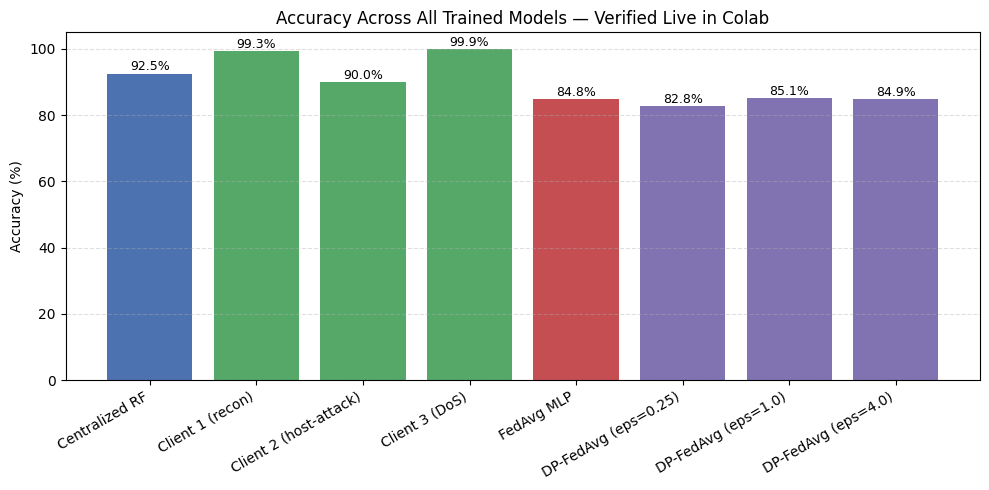

In [14]:
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Model": ["Centralized RF", "Client 1 (recon)", "Client 2 (host-attack)", "Client 3 (DoS)",
              "FedAvg MLP", "DP-FedAvg (eps=0.25)", "DP-FedAvg (eps=1.0)", "DP-FedAvg (eps=4.0)"],
    "Accuracy": [0.9249, 0.9928, 0.8995, 0.9985, 0.8481, 0.8277, 0.8506, 0.8486],
    "F1": [0.9576, 0.9959, 0.9444, 0.9991, 0.9067, 0.8923, 0.9085, 0.9070],
})

display(results)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4C72B0', '#55A868', '#55A868', '#55A868', '#C44E52', '#8172B2', '#8172B2', '#8172B2']
bars = ax.bar(results["Model"], results["Accuracy"] * 100, color=colors)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy Across All Trained Models — Verified Live in Colab")
ax.set_ylim(0, 105)
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, results["Accuracy"]):
    ax.text(bar.get_x() + bar.get_width()/2, val*100 + 1, f"{val*100:.1f}%", ha='center', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('results_summary.png', dpi=150)
plt.show()

In [16]:
!pip install shap -q

Retraining the DP-FedAvg model (epsilon=1.0) to explain...


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:609: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(


Building background sample and computing SHAP values (this takes a couple minutes)...

Feature importance (mean |SHAP value|) for attack prediction:
  State_charging: 0.1575
  State_idle: 0.0914
  bus_voltage_V: 0.0754
  power_mW: 0.0296
  shunt_voltage: 0.0295
  current_mA: 0.0274


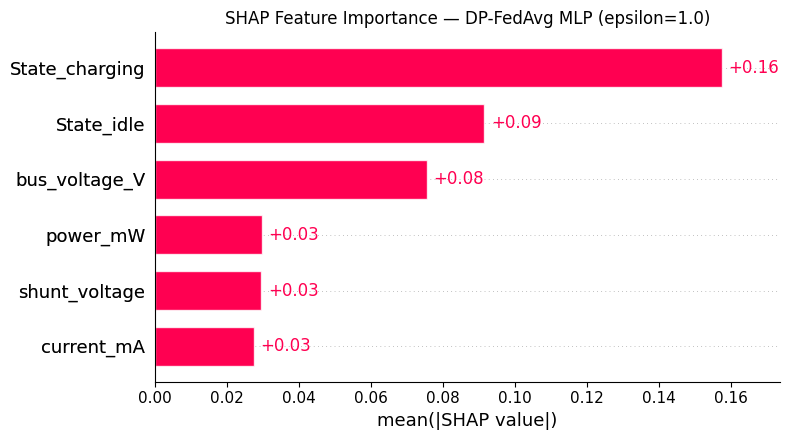

In [17]:
import shap

def train_dp_model_for_shap(epsilon=1.0, noise_multiplier=0.01, rounds=20, local_epochs=3):
    model = make_model(len(NUMERIC_COLUMNS) + len(state_categories))
    noise_rng = np.random.default_rng(42)
    for r in range(1, rounds + 1):
        local_models = []
        for c in clients:
            local_model = copy.deepcopy(model)
            for _ in range(local_epochs):
                local_model.partial_fit(c["X_train"], c["y_train"])
            local_models.append(local_model)
        model = average_models(local_models, row_counts)
        add_gaussian_noise(model, epsilon, noise_multiplier, noise_rng)
    return model

print("Retraining the DP-FedAvg model (epsilon=1.0) to explain...")
shap_model = train_dp_model_for_shap()

feature_names = [*NUMERIC_COLUMNS, *(f"State_{s}" for s in state_categories)]
X_train_all = np.vstack([c["X_train"] for c in clients])

print("Building background sample and computing SHAP values (this takes a couple minutes)...")
rng = np.random.default_rng(42)
background = shap.sample(X_train_all, 100, random_state=42)
sample_idx = rng.choice(len(X_test), size=min(200, len(X_test)), replace=False)

explainer = shap.Explainer(shap_model.predict_proba, background, algorithm="exact", feature_names=feature_names)
explanation = explainer(X_test[sample_idx])

# Extract SHAP values for the "attack" class (index 0, since classes_ = ['attack','benign'])
attack_values = explanation.values[:, :, 0]
importance = np.abs(attack_values).mean(axis=0)
top_idx = np.argsort(importance)[::-1]

print("\nFeature importance (mean |SHAP value|) for attack prediction:")
for i in top_idx:
    print(f"  {feature_names[i]}: {importance[i]:.4f}")

shap.plots.bar(shap.Explanation(values=attack_values, base_values=explanation.base_values[:,0],
                                  data=explanation.data, feature_names=feature_names), show=False)
plt.title("SHAP Feature Importance — DP-FedAvg MLP (epsilon=1.0)")
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
from google.colab import files
files.download('results_summary.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>